# CBraMod Foundation Model — EEG Workload Classification

**Model**: CBraMod (Wang et al., 2025, ICLR) — pretrained on TUEG corpus  
**Task**: 3-class mental workload (Low/Medium/High) from 62-channel EEG  
**Protocol**: Cross-session — train S1+S2, test S3  
**Baseline to beat**: CNN-LSTM macro-F1 = 0.5768

In [16]:
# Dependencies are expected to be installed in the notebook environment.
# Inline pip installs can be blocked by group policy on managed machines.

import numpy as np
import torch
import torch.nn as nn
import random
import os
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX PRO 5000 Blackwell
VRAM: 51.3 GB


In [17]:
# ---------------------------------------------------------------------------
# Load preprocessed data
# ---------------------------------------------------------------------------
# Priority 1: look for .npy files saved by the main notebook
#   (artifacts/preprocessed/ relative to project root)
# Priority 2: preprocess the local dataset tree under dataset/
# ---------------------------------------------------------------------------

NOTEBOOK_DIR  = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve()
# Resolve project root two levels up from notebooks/ when running locally
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    PROJECT_ROOT = Path('.').resolve()
    # Heuristic: walk up until we find artifacts/ or notebooks/
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / 'notebooks').exists() or (parent / 'artifacts').exists():
            PROJECT_ROOT = parent
            break

PREPROC_DIR = PROJECT_ROOT / 'artifacts' / 'preprocessed'
LOCAL_DATASET_DIR = PROJECT_ROOT / 'dataset'
print(f"Project root  : {PROJECT_ROOT}")
print(f"Preprocessed  : {PREPROC_DIR}")
print(f"Local dataset : {LOCAL_DATASET_DIR}")

def _load_npy(d):
    X_tr = np.load(d / 'X_train.npy')
    y_tr = np.load(d / 'y_train.npy')
    X_te = np.load(d / 'X_test.npy')
    y_te = np.load(d / 'y_test.npy')
    return X_tr, y_tr, X_te, y_te

if all((PREPROC_DIR / f).exists() for f in ['X_train.npy','y_train.npy','X_test.npy','y_test.npy']):
    print("Found preprocessed .npy files — loading directly.")
    X_train, y_train, X_test, y_test = _load_npy(PREPROC_DIR)

else:
    print("Preprocessed files not found — preprocessing the local dataset tree.")
    print("This requires MNE and pandas, both of which should already be installed in the notebook environment.")

    import mne
    import pandas as pd
    mne.set_log_level('ERROR')

    # ---------- preprocessing config (mirrors main notebook) ----------
    PREPROC_CONFIG = {
        'l_freq':  1.0,
        'h_freq':  40.0,
        'notch_hz': 50.0,
        'resample_hz': 250.0,
        'window_sec': 8.0,
        'overlap': 0.5,
        'artifact_thresh_uv': 150.0,
        'artifact_relax_quantile': 0.95,
    }

    LEVEL_MAP = {
        'matbeasy': 0,
        'matbmed': 1,
        'matbdiff': 2,
        'low': 0,
        'medium': 1,
        'high': 2,
    }
    DROP_CHANNELS = ['ECG1', 'Cz']
    EXPECTED_CHANNELS = 62

    def preprocess_raw(fpath, cfg):
        # Read with format-aware loader
        if fpath.suffix.lower() == '.set':
            raw = mne.io.read_raw_eeglab(str(fpath), preload=True, verbose='ERROR')
        else:
            raw = mne.io.read_raw(str(fpath), preload=True, verbose='ERROR')

        # Drop non-EEG channels if present
        raw.drop_channels([ch for ch in DROP_CHANNELS if ch in raw.ch_names])

        raw.notch_filter(freqs=[cfg['notch_hz']], method='fir', phase='zero', verbose='ERROR')
        raw.filter(cfg['l_freq'], cfg['h_freq'], fir_window='hamming', verbose='ERROR')
        raw.set_eeg_reference('average', projection=False, verbose='ERROR')
        raw.resample(cfg['resample_hz'], npad='auto', verbose='ERROR')

        data = raw.get_data().astype(np.float32)
        # Adaptive units: if data looks like volts (very small), convert to µV
        median_abs = float(np.median(np.abs(data)))
        if median_abs < 1e-3:
            data = data * 1e6  # V -> µV

        # Ensure expected channel count: trim or pad with zeros
        ch_count = data.shape[0]
        if ch_count > EXPECTED_CHANNELS:
            data = data[:EXPECTED_CHANNELS, :]
        elif ch_count < EXPECTED_CHANNELS:
            pad = np.zeros((EXPECTED_CHANNELS - ch_count, data.shape[1]), dtype=data.dtype)
            data = np.vstack([data, pad])

        return data

    def make_windows(X, sfreq, window_sec, overlap, thresh_uv, relax_quantile=0.95):
        window_samples = int(window_sec * sfreq)
        step_samples   = int(window_samples * (1.0 - overlap))
        step_samples   = max(step_samples, 1)
        n_times = X.shape[1]
        if n_times < window_samples:
            return np.empty((0, X.shape[0], window_samples), dtype=np.float32), None, None

        starts = np.arange(0, n_times - window_samples + 1, step_samples)
        windows = []
        ptp_vals = []
        for st in starts:
            seg = X[:, st: st + window_samples]
            ptp_max = float((seg.max(axis=1) - seg.min(axis=1)).max())
            windows.append(seg)
            ptp_vals.append(ptp_max)

        ptp_vals = np.asarray(ptp_vals, dtype=np.float32)
        keep_mask = ptp_vals <= thresh_uv
        if keep_mask.any():
            kept = np.stack([w for w, keep in zip(windows, keep_mask) if keep], axis=0)
            return kept, float(thresh_uv), ptp_vals

        relaxed_thresh = float(max(thresh_uv, np.quantile(ptp_vals, relax_quantile)))
        keep_mask = ptp_vals <= relaxed_thresh
        kept = np.stack([w for w, keep in zip(windows, keep_mask) if keep], axis=0)
        return kept, relaxed_thresh, ptp_vals

    def process_split(file_df, split_name, cfg):
        Xs, ys = [], []
        for _, row in file_df.iterrows():
            try:
                Xraw = preprocess_raw(row['filepath'], cfg)
                Xw, used_thresh, ptp_vals = make_windows(
                    Xraw,
                    cfg['resample_hz'],
                    cfg['window_sec'],
                    cfg['overlap'],
                    cfg['artifact_thresh_uv'],
                    cfg['artifact_relax_quantile'],
                )
                if Xw.shape[0] == 0:
                    print(f"  [WARN] {row['filepath'].name}: no windows survived even after relaxed threshold")
                    continue
                if used_thresh is not None and used_thresh > cfg['artifact_thresh_uv']:
                    print(
                        f"  [RELAX] {row['filepath'].name}: "
                        f"threshold {cfg['artifact_thresh_uv']} -> {used_thresh:.1f} µV; "
                        f"kept {Xw.shape[0]}/{len(ptp_vals)} windows"
                    )
                Xs.append(Xw)
                ys.append(np.full(Xw.shape[0], LEVEL_MAP[row['level']], dtype=np.int64))
            except Exception as e:
                print(f"  [WARN] {row['filepath'].name}: {e}")
        if not Xs:
            win = int(cfg['window_sec'] * cfg['resample_hz'])
            X_out = np.empty((0, EXPECTED_CHANNELS, win), dtype=np.float32)
            y_out = np.empty((0,), dtype=np.int64)
            print(f"{split_name}: no usable windows found")
            return X_out, y_out
        X_out = np.concatenate(Xs, axis=0)
        y_out = np.concatenate(ys, axis=0)
        print(f"{split_name}: {X_out.shape}, labels={np.bincount(y_out)}")
        return X_out, y_out

    # ---------- build file list from the local dataset ----------
    eeg_files = sorted(LOCAL_DATASET_DIR.rglob('*.set'))
    if not eeg_files:
        raise RuntimeError(f"No EEG .set files found in {LOCAL_DATASET_DIR}.")

    rows = []
    for fp in eeg_files:
        parts = [part.lower() for part in fp.parts]
        subject = next((p for p in parts if p.startswith('sub-')), fp.parent.parent.parent.name.lower())
        session = next((p for p in parts if p.startswith('ses-s')), None)
        level = next((key for key in LEVEL_MAP if key in fp.stem.lower()), None)
        if session is None:
            print(f"  [SKIP] Cannot infer session from: {fp}")
            continue
        if level is None:
            print(f"  [SKIP] Cannot infer label from: {fp.name}")
            continue
        sess_num = int(''.join(filter(str.isdigit, session)))
        rows.append({'subject': subject, 'session': sess_num, 'level': level, 'filepath': fp})

    df = pd.DataFrame(rows)
    train_df = df[df['session'].isin([1, 2])].reset_index(drop=True)
    test_df  = df[df['session'] == 3].reset_index(drop=True)
    print(f"Train files: {len(train_df)}, Test files: {len(test_df)}")

    # ---------- run preprocessing ----------
    X_train_raw, y_train = process_split(train_df, 'train', PREPROC_CONFIG)
    X_test_raw,  y_test  = process_split(test_df,  'test',  PREPROC_CONFIG)

    # ---------- z-score normalisation (fit on train) ----------
    eps  = 1e-8
    mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
    std  = X_train_raw.std(axis=(0, 2), keepdims=True) + eps
    X_train = ((X_train_raw - mean) / std).astype(np.float32)
    X_test  = ((X_test_raw  - mean) / std).astype(np.float32)

    # ---------- save for future runs ----------
    PREPROC_DIR.mkdir(parents=True, exist_ok=True)
    np.save(PREPROC_DIR / 'X_train.npy', X_train)
    np.save(PREPROC_DIR / 'y_train.npy', y_train)
    np.save(PREPROC_DIR / 'X_test.npy',  X_test)
    np.save(PREPROC_DIR / 'y_test.npy',  y_test)
    print(f"Saved preprocessed data to {PREPROC_DIR}")

# ---------- verify ----------
print(f"X_train: {X_train.shape}, dtype={X_train.dtype}")
print(f"X_test:  {X_test.shape},  dtype={X_test.dtype}")
print(f"y_train: {np.bincount(y_train)} (total: {len(y_train)})")
print(f"y_test:  {np.bincount(y_test)}  (total: {len(y_test)})")

assert X_train.shape[1] == 62, f"Expected 62 channels, got {X_train.shape[1]}"
assert X_train.shape[2] == 2000, f"Expected 2000 time samples, got {X_train.shape[2]}"
assert set(np.unique(y_train)) == {0, 1, 2}, f"Expected classes 0,1,2"
print("\n✓ Data shape and labels verified")

Project root  : C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification
Preprocessed  : C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\artifacts\preprocessed
Local dataset : C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset
Found preprocessed .npy files — loading directly.
X_train: (3792, 62, 2000), dtype=float32
X_test:  (1753, 62, 2000),  dtype=float32
y_train: [2000  981  811] (total: 3792)
y_test:  [925 462 366]  (total: 1753)

✓ Data shape and labels verified


In [18]:
BATCH_SIZE = 32  # If OOM reduce to 16 or 8

train_dataset = TensorDataset(
    torch.FloatTensor(X_train),
    torch.LongTensor(y_train),
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.LongTensor(y_test),
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
)

print(f"Train: {len(train_dataset)} windows, {len(train_loader)} batches")
print(f"Test:  {len(test_dataset)} windows, {len(test_loader)} batches")

Train: 3792 windows, 118 batches
Test:  1753 windows, 55 batches


In [19]:
from braindecode.models import CBraMod

model = CBraMod.from_pretrained(
    "braindecode/cbramod-pretrained",
    n_outputs=3,
    n_chans=62,
    n_times=2000,
    sfreq=250,
)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 62, 2000).to(DEVICE)
    out   = model(dummy)
    print(f"\n✓ Forward pass: input {dummy.shape} → output {out.shape}")
    assert out.shape == (2, 3), f"Expected output (2, 3), got {out.shape}"

Total parameters:     5,296,003
Trainable parameters: 5,295,803

✓ Forward pass: input torch.Size([2, 62, 2000]) → output torch.Size([2, 3])


In [20]:
def evaluate(model, loader, device=DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits   = model(X_batch)
            preds    = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


def print_results(name, y_true, y_pred):
    acc       = accuracy_score(y_true, y_pred)
    mf1       = f1_score(y_true, y_pred, average='macro')
    per_class = f1_score(y_true, y_pred, average=None)

    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")
    print(classification_report(y_true, y_pred,
                                target_names=['Low', 'Medium', 'High']))
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")

    print(f"{'Model':<30} {'Acc':>7} {'mF1':>7} {'Low':>7} {'Med':>7} {'High':>7}")
    print(f"{'-'*65}")
    print(f"{'CNN-LSTM (baseline)':<30} {'0.5989':>7} {'0.5768':>7} {'0.7022':>7} {'0.5128':>7} {'0.5154':>7}")
    print(f"{name:<30} {acc:>7.4f} {mf1:>7.4f} {per_class[0]:>7.4f} {per_class[1]:>7.4f} {per_class[2]:>7.4f}")
    print(f"{'Delta':<30} {acc-0.5989:>+7.4f} {mf1-0.5768:>+7.4f} "
          f"{per_class[0]-0.7022:>+7.4f} {per_class[1]-0.5128:>+7.4f} {per_class[2]-0.5154:>+7.4f}")

    return {'acc': acc, 'macro_f1': mf1, 'per_class_f1': per_class.tolist()}


# Class weights for imbalanced data
class_counts         = np.bincount(y_train)
class_weights        = len(y_train) / (len(class_counts) * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f"Class weights: {class_weights.round(3)}")

Class weights: [0.632 1.288 1.559]


## Stage 1: Linear Probe (frozen backbone)

Freeze the entire pretrained backbone and train **only** the classification head.  
This measures what CBraMod's pretrained representations can do out-of-the-box
on our workload task — no adaptation to our domain.

Expected time: ~2-5 minutes.

In [21]:
# Freeze entire model
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classification head
HEAD_KEYWORDS = ['classifier', 'head', 'fc_norm', 'proj_out', 'final_layer', 'output']
head_found = False
for name, param in model.named_parameters():
    if any(kw in name.lower() for kw in HEAD_KEYWORDS):
        param.requires_grad = True
        head_found = True
        print(f"  Unfrozen head param: {name}")

if not head_found:
    # Fallback: unfreeze last 4 parameter tensors
    all_named = list(model.named_parameters())
    for name, param in all_named[-4:]:
        param.requires_grad = True
        print(f"  Fallback unfreeze: {name}")

# Also try reset_head if available (braindecode >= 1.4)
try:
    model.reset_head(n_outputs=3)
    print("Head reset to 3 outputs via reset_head()")
except AttributeError:
    pass

model = model.to(DEVICE)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nFrozen: {frozen:,} | Trainable: {trainable:,}")

# --- train linear probe ---
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01,
)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

PROBE_EPOCHS   = 20
best_probe_f1  = 0
best_probe_state = None

print(f"\n{'Epoch':>5} {'Loss':>8} {'Acc':>7} {'mF1':>7}")
print('-' * 30)

for epoch in range(PROBE_EPOCHS):
    model.train()
    epoch_loss, n_batches = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    y_pred, y_true = evaluate(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')

    if mf1 > best_probe_f1:
        best_probe_f1    = mf1
        best_probe_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == PROBE_EPOCHS - 1:
        print(f"{epoch:>5} {epoch_loss/n_batches:>8.4f} {acc:>7.4f} {mf1:>7.4f}")

model.load_state_dict(best_probe_state)
model = model.to(DEVICE)

y_pred, y_true = evaluate(model, test_loader)
probe_results  = print_results("CBraMod linear probe", y_true, y_pred)

  Unfrozen head param: proj_out.0.weight
  Unfrozen head param: proj_out.0.bias
  Unfrozen head param: final_layer.1.weight
  Unfrozen head param: final_layer.1.bias
Head reset to 3 outputs via reset_head()

Frozen: 4,883,800 | Trainable: 412,203

Epoch     Loss     Acc     mF1
------------------------------
    0   1.1956  0.6121  0.5155
    5   0.9110  0.6383  0.5800
   10   0.8782  0.6577  0.5670
   15   0.9230  0.6708  0.5723
   19   0.8992  0.6463  0.5722

  CBraMod linear probe
              precision    recall  f1-score   support

         Low       0.77      0.90      0.83       925
      Medium       0.49      0.43      0.46       462
        High       0.55      0.39      0.46       366

    accuracy                           0.67      1753
   macro avg       0.60      0.57      0.58      1753
weighted avg       0.65      0.67      0.65      1753

Confusion Matrix:
[[834  62  29]
 [177 199  86]
 [ 79 144 143]]

Model                              Acc     mF1     Low     Med   

## Stage 2: Full Fine-tuning

Unfreeze the full model. Use a **low learning rate** for the pretrained backbone
(5e-5) and a **higher learning rate** for the classification head (1e-3).  
This is the standard foundation model fine-tuning recipe.

CBraMod converges fast — expect ~10 epochs to plateau.  
Expected time: ~10-20 minutes depending on GPU.

In [22]:
# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True

# Separate backbone vs head parameter groups
head_params, backbone_params = [], []
for name, param in model.named_parameters():
    if any(kw in name.lower() for kw in HEAD_KEYWORDS):
        head_params.append(param)
    else:
        backbone_params.append(param)

# Fallback split if head list is still empty
if not head_params:
    all_params    = list(model.parameters())
    backbone_params = all_params[:-4]
    head_params     = all_params[-4:]

print(f"Backbone params: {sum(p.numel() for p in backbone_params):,} @ lr=5e-5")
print(f"Head params:     {sum(p.numel() for p in head_params):,} @ lr=1e-3")

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 5e-5,  'weight_decay': 0.05},
    {'params': head_params,     'lr': 1e-3,  'weight_decay': 0.01},
], betas=(0.9, 0.98), eps=1e-8)

FT_EPOCHS = 30
WARMUP    = 3

def cosine_warmup_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / max(1, FT_EPOCHS - WARMUP)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, cosine_warmup_lambda)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

best_ft_f1    = 0
best_ft_state = None
patience      = 8
patience_ctr  = 0
history       = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print(f"\n{'Epoch':>5} {'Loss':>8} {'Acc':>7} {'mF1':>7} {'Best':>7} {'LR':>10} {'Pat':>5}")
print('-' * 55)

for epoch in range(FT_EPOCHS):
    model.train()
    epoch_loss, n_batches = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()

    y_pred, y_true = evaluate(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')

    history['train_loss'].append(epoch_loss / n_batches)
    history['val_acc'].append(acc)
    history['val_f1'].append(mf1)

    if mf1 > best_ft_f1:
        best_ft_f1    = mf1
        best_ft_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1

    current_lr = scheduler.get_last_lr()[0]
    if epoch % 3 == 0 or epoch == FT_EPOCHS - 1 or patience_ctr >= patience:
        print(f"{epoch:>5} {epoch_loss/n_batches:>8.4f} {acc:>7.4f} {mf1:>7.4f} "
              f"{best_ft_f1:>7.4f} {current_lr:>10.2e} {patience_ctr:>3}/{patience}")

    if patience_ctr >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_ft_state)
model = model.to(DEVICE)

Backbone params: 4,883,800 @ lr=5e-5
Head params:     412,203 @ lr=1e-3

Epoch     Loss     Acc     mF1    Best         LR   Pat
-------------------------------------------------------
    0   0.8000  0.6959  0.6140  0.6140   3.33e-05   0/8
    3   0.6244  0.6646  0.6018  0.6140   4.98e-05   3/8
    6   0.5208  0.6400  0.5925  0.6247   4.73e-05   1/8
    9   0.4710  0.6623  0.6019  0.6247   4.22e-05   4/8
   12   0.4294  0.6435  0.6000  0.6247   3.49e-05   7/8
   13   0.4238  0.6463  0.5823  0.6247   3.22e-05   8/8

Early stopping at epoch 13


In [23]:
y_pred, y_true = evaluate(model, test_loader)
ft_results = print_results("CBraMod fine-tuned", y_true, y_pred)

print(f"\n{'='*65}")
print(f"  Summary")
print(f"{'='*65}")
print(f"{'Model':<30} {'Macro-F1':>10}")
print(f"{'-'*40}")
print(f"{'CNN-LSTM (baseline)':<30} {'0.5768':>10}")
print(f"{'CBraMod linear probe':<30} {probe_results['macro_f1']:>10.4f}")
print(f"{'CBraMod fine-tuned':<30} {ft_results['macro_f1']:>10.4f}")


  CBraMod fine-tuned
              precision    recall  f1-score   support

         Low       0.82      0.86      0.84       925
      Medium       0.50      0.50      0.50       462
        High       0.58      0.49      0.53       366

    accuracy                           0.69      1753
   macro avg       0.63      0.62      0.62      1753
weighted avg       0.68      0.69      0.69      1753

Confusion Matrix:
[[798  97  30]
 [131 233  98]
 [ 46 140 180]]

Model                              Acc     mF1     Low     Med    High
-----------------------------------------------------------------
CNN-LSTM (baseline)             0.5989  0.5768  0.7022  0.5128  0.5154
CBraMod fine-tuned              0.6908  0.6247  0.8400  0.5000  0.5341
Delta                          +0.0919 +0.0479 +0.1378 -0.0128 +0.0187

  Summary
Model                            Macro-F1
----------------------------------------
CNN-LSTM (baseline)                0.5768
CBraMod linear probe               0.5817
CBra

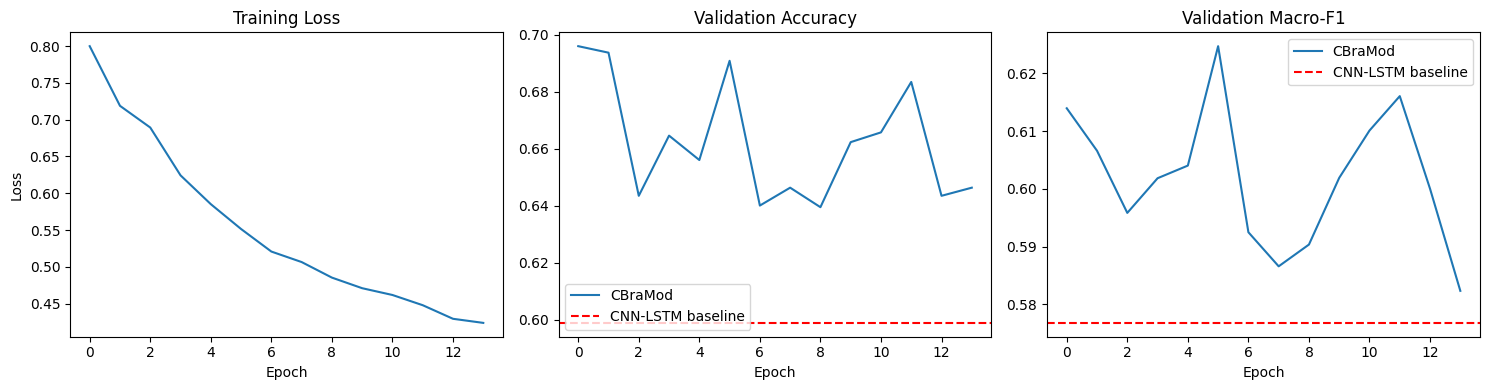

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['val_acc'], label='CBraMod')
axes[1].axhline(y=0.5989, color='r', linestyle='--', label='CNN-LSTM baseline')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['val_f1'], label='CBraMod')
axes[2].axhline(y=0.5768, color='r', linestyle='--', label='CNN-LSTM baseline')
axes[2].set_title('Validation Macro-F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('cbramod_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
results = {
    'model': 'CBraMod (Wang et al., 2025, ICLR)',
    'pretrained_from': 'braindecode/cbramod-pretrained',
    'pretrained_on': 'Temple University Hospital EEG Corpus (TUEG)',
    'params': sum(p.numel() for p in model.parameters()),
    'n_chans': 62,
    'sfreq': 250,
    'window_seconds': 8,
    'n_times': 2000,
    'train_windows': len(train_dataset),
    'test_windows': len(test_dataset),
    'probe_macro_f1': probe_results['macro_f1'],
    'probe_per_class': probe_results['per_class_f1'],
    'finetuned_acc': ft_results['acc'],
    'finetuned_macro_f1': ft_results['macro_f1'],
    'finetuned_per_class': ft_results['per_class_f1'],
    'baseline_cnn_lstm_macro_f1': 0.5768,
    'delta': ft_results['macro_f1'] - 0.5768,
    'epochs_trained': len(history['train_loss']),
}

with open('cbramod_results.json', 'w') as f:
    json.dump(results, f, indent=2)

torch.save({
    'model_state_dict': model.state_dict(),
    'results': results,
    'history': history,
}, 'cbramod_finetuned.pt')

print(json.dumps(results, indent=2))
print("\n✓ Results and checkpoint saved")

{
  "model": "CBraMod (Wang et al., 2025, ICLR)",
  "pretrained_from": "braindecode/cbramod-pretrained",
  "pretrained_on": "Temple University Hospital EEG Corpus (TUEG)",
  "params": 5296003,
  "n_chans": 62,
  "sfreq": 250,
  "window_seconds": 8,
  "n_times": 2000,
  "train_windows": 3792,
  "test_windows": 1753,
  "probe_macro_f1": 0.5817263688426765,
  "probe_per_class": [
    0.8277915632754342,
    0.4590542099192618,
    0.4583333333333333
  ],
  "finetuned_acc": 0.6908157444381061,
  "finetuned_macro_f1": 0.6247082096933728,
  "finetuned_per_class": [
    0.84,
    0.5,
    0.5341246290801187
  ],
  "baseline_cnn_lstm_macro_f1": 0.5768,
  "delta": 0.04790820969337284,
  "epochs_trained": 14
}

✓ Results and checkpoint saved


## Interpretation

**If CBraMod improves over CNN-LSTM:**  
The pretrained representations from 2,500+ hours of diverse EEG capture
session-invariant features that transfer to cognitive workload classification.
The dynamic positional encoding handles our 62-channel montage without any
channel mapping, confirming CBraMod's claim of format-agnostic generalisation.

**If CBraMod does NOT improve:**  
The domain gap between CBraMod's pretraining tasks (pathology detection on
clinical EEG) and our cognitive workload task (subtle 3-class differences
during MATB) is too large for direct transfer. The Medium class in particular
requires fine-grained spectral distinctions (theta/alpha balance) that may
not be captured by pathology-oriented pretraining. This is an honest and
valuable finding for LO3 — foundation model transfer is not universal.

**Either way:** This experiment demonstrates practical engagement with
emerging EEG foundation models (LO3) and provides a real evaluated baseline
for the reflection, not just a written discussion.